# ROAS가 220%인데 왜 우리는 적자예요? — 유닛 이코노믹스 실습

본문에서 설명한 LTV:CAC 계산과 다양한 형태의 보정을 직접 실습해 보겠습니다.

## 7.4.1. 실습용 데이터 준비

실습에는 3개의 테이블이 필요합니다. 마케팅 비용, 유저 테이블, 그리고 결제 로그입니다.
각각 CAC 계산의 분자(마케팅 비용)와 분모(유저 테이블), 그리고 LTV 계산의 원천(결제 로그)이
됩니다.

| 파일 | 칼럼 | 설명 |
| --- | --- | --- |
| `marketing_costs.csv` | month, channel, media_cost_krw, other_cost_krw | 월×채널 마케팅 비용. other는 에이전시 수수료·소재 제작비 |
| `users.csv` | user_id, channel, signup_date | 유입 유저 명부 — **결제 안 한 유저도 포함** |
| `payments.csv` | user_id, payment_date, amount_krw | 결제 건별 로그. 금액은 전부 '매출' |

마케팅 채널은 검색, 디스플레이, 리타겟팅, 브랜드, 오가닉까지 다섯 개입니다(오가닉 채널은
광고비가 없으므로 비용 테이블에는 없고 유저 테이블에만 있습니다). 노트북 환경 구성은 아래와
같습니다. 7.2.1의 변동비 가정(합계 35%)에 따라 공헌이익률 65%를 상수로 선언해 두고 시작합니다.

내 데이터에 적용할 때 바꿀 값은 다섯 군데입니다. 이 `CM_RATIO`, 7.4.2의 기준월(2025-04-01),
7.4.3의 장기 코호트 구간(2024-01-01~2024-12-31), 7.4.5의 채널·획득월("search", "2025-04" 등),
7.4.6의 `TARGET_PAYBACK`입니다.


In [ ]:
# 의존성 설치
%pip install -q -r requirements.txt

In [2]:
# 실습 데이터 환경 구성
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect()
for t in ["marketing_costs", "users", "payments"]:
    q = f"CREATE TABLE {t} AS SELECT * FROM read_csv_auto('data/{t}.csv')"
    con.execute(q)

CM_RATIO = 0.65  # 공헌이익률 — 변동비 가정(합계 35%)은 위 문단 참조

## 7.4.2. 채널별 CAC — fully-loaded

2025년 4월 한 달을 기준으로 채널별 CAC를 계산합니다. 포인트는 두 가지입니다. 첫째,
오가닉은 광고비가 없으므로 제외합니다. (SQL에서 비용 테이블과 조인하는 순간 분모에서
자연스럽게 빠집니다.) 둘째, 매체비만 반영한 CAC(cac_media)와 기타 비용까지 포함한
CAC(cac_fully_loaded)를 구분해서 계산합니다.


In [3]:
cac = con.execute("""
    SELECT c.channel
         , u.new_users
         , ROUND(c.media_cost_krw / u.new_users) AS cac_media
         , ROUND((c.media_cost_krw + c.other_cost_krw)
                 / u.new_users) AS cac_fully_loaded
    FROM marketing_costs c
    JOIN (
        SELECT channel, COUNT(*) AS new_users
        FROM users
        WHERE date_trunc('month', signup_date) = DATE '2025-04-01'
        GROUP BY channel
    ) u USING (channel)
    WHERE c.month = DATE '2025-04-01'
    ORDER BY u.new_users DESC
""").df()
cac

,channel,new_users,cac_media,cac_fully_loaded
0,search,1000,9890.0,11500.0
1,brand,750,22389.0,28000.0
2,display,500,5016.0,5700.0
3,retargeting,250,3240.0,3600.0


In [4]:
apr = con.execute("""
    SELECT SUM(media_cost_krw) AS media
         , SUM(media_cost_krw + other_cost_krw) AS fully
    FROM marketing_costs WHERE month = DATE '2025-04-01'
""").df().iloc[0]
n_paid = cac.new_users.sum()
media_cac, full_cac = apr.media / n_paid, apr.fully / n_paid
print(f"2025-04 유료 유입 : {n_paid:,}명")
print(f"매체비 기준 CAC : {media_cac:,.0f}원")
print(f"fully-loaded CAC : {full_cac:,.0f}원 (+{full_cac / media_cac - 1:.0%})")

2025-04 유료 유입 : 2,500명
매체비 기준 CAC : 12,000원
fully-loaded CAC : 14,500원 (+21%)


7.2.2에서 봤던 12,000원 → 14,500원이 그대로 나옵니다. 매체비만 보면 마케팅 리드의
계산이 맞지만, 에이전시 수수료와 소재 제작비를 얹는 순간 CAC가 20% 넘게 올라가는 게
보입니다.


## 7.4.3. LTR을 LTV공헌이익으로 - 장기 코호트 백테스트

LTV를 예측 모델 없이 계산하는 간단한 방법은 획득한 지 1년이 지난 코호트의 결제를
실제로 다 세어보는 것입니다. (4장에서 설명한 장기 코호트 기반 집계입니다. 실측 지평도
4장과 같은 12개월로 맞춥니다.) 2024-01~2024-12에 유입된 유저들의 12개월 누적
결제 금액(LTR)을 구하고, 공헌이익률 65%를 곱해 LTV로 바꿉니다.


In [5]:
# 장기 코호트(획득 12개월 경과) 뷰 - 7.4.6에서도 재사용
con.execute("""
    CREATE OR REPLACE VIEW mature AS
    SELECT user_id, channel, date_trunc('month', signup_date) AS cohort_month
    FROM users
    WHERE signup_date BETWEEN DATE '2024-01-01' AND DATE '2024-12-31'
""")

장기 코호트 뷰를 만들었으니, 이제 유저별 12개월 결제를 집계해 채널별 LTV로 바꿉니다.

In [6]:
ltv = con.execute(f"""
    WITH rev AS (  -- 유저별 12개월 누적 결제금액 (미결제 유저는 0)
      SELECT m.channel, m.user_id, COALESCE(SUM(p.amount_krw), 0) AS ltr_12m
      FROM mature m
      LEFT JOIN payments p
        ON p.user_id = m.user_id
       AND p.payment_date < m.cohort_month + INTERVAL 12 MONTH
      GROUP BY 1, 2
    )
    SELECT channel
         , COUNT(*) AS users
         , ROUND(AVG(ltr_12m)) AS ltr
         , ROUND(AVG(ltr_12m) * {CM_RATIO}) AS ltv_cm
    FROM rev
    GROUP BY channel
    ORDER BY ltv_cm DESC
""").df()
ltv

,channel,users,ltr,ltv_cm
0,search,1440,50762.0,32995.0
1,organic,1440,39984.0,25989.0
2,brand,1080,36940.0,24011.0
3,retargeting,360,36939.0,24010.0
4,display,720,9082.0,5903.0


In [7]:
paid_ltr = ltv[ltv.channel != "organic"].pipe(  # 채널 LTR의 유저 수 가중 평균
    lambda d: (d.ltr * d.users).sum() / d.users.sum())
paid_ltv = paid_ltr * CM_RATIO
r1, r2, r3 = paid_ltr / media_cac, paid_ltv / media_cac, paid_ltv / full_cac

print(f"유료 유입 유저의 LTR : {paid_ltr:,.0f}원")
print(f"LTV(공헌이익) = LTR x 65% : {paid_ltv:,.0f}원")
print(f"[1] LTR / 매체비 CAC : {r1:.1f} <- 마케팅 리드의 계산")
print(f"[2] LTV / 매체비 CAC : {r2:.1f} <- 공헌이익으로 교체")
print(f"[3] LTV / fully-loaded CAC : {r3:.1f} <- 비용을 fully-loaded로")

유료 유입 유저의 LTR : 36,897원
LTV(공헌이익) = LTR x 65% : 23,983원
[1] LTR / 매체비 CAC : 3.1 <- 마케팅 리드의 계산
[2] LTV / 매체비 CAC : 2.0 <- 공헌이익으로 교체
[3] LTV / fully-loaded CAC : 1.7 <- 비용을 fully-loaded로


표 7.1→7.3→7.4의 흐름이 데이터에서 그대로 복원됐습니다. 매출 기준으로 LTV:CAC를 봤을
때는 3.1이었지만, 지표의 '단위'를 공헌이익과 fully-loaded로 맞추고 나니 1.7이 됐습니다.


## 7.4.4. 채널별로 쪼개보기

7.4.2의 CAC와 7.4.3의 LTV를 채널 단위로 붙이면 7.2.3의 채널 표가 완성됩니다.


In [8]:
table = cac.merge(ltv[["channel", "ltv_cm"]], on="channel", how="outer")
table["share"] = (table.new_users / n_paid).map(
    lambda x: f"{x:.0%}" if x == x else "-")  # NaN(오가닉)은 '-' 표기
table["ratio"] = (table.ltv_cm / table.cac_fully_loaded).round(1)

# 유료 전체 행 추가
total = pd.DataFrame([{
    "channel": "paid_total", "new_users": n_paid, "share": "100%",
    "cac_fully_loaded": full_cac, "ltv_cm": paid_ltv,
    "ratio": round(paid_ltv / full_cac, 1),
}])
cols = ["channel", "share", "cac_fully_loaded", "ltv_cm", "ratio"]
out = pd.concat([table, total])[cols].reset_index(drop=True)
out["ltv_cm"] = out.ltv_cm.round(0)
out.fillna("-")

,channel,share,cac_fully_loaded,ltv_cm,ratio
0,brand,30%,28000.0,24011.0,0.9
1,display,20%,5700.0,5903.0,1.0
2,organic,-,-,25989.0,-
3,retargeting,10%,3600.0,24010.0,6.7
4,search,40%,11500.0,32995.0,2.9
5,paid_total,100%,14500.0,23983.0,1.7


## 7.4.5. 회수 곡선과 회수 기간

2025년 4월 검색 코호트를 대상으로, 회수 기간 표를 그려보겠습니다.

회수 곡선은 아래에서 표와 차트에 두 번 쓰이므로, 채널과 획득월을 인자로 받는 함수로 먼저 만들어 둡니다.


In [9]:
def payback_df(channel, cohort_month, max_m=11):
    """채널×획득월 코호트의 월별 공헌이익과 누적 회수율(÷ CAC 총액)."""
    df = con.execute(f"""
        WITH cohort AS (
            SELECT user_id FROM users
            WHERE channel = '{channel}'
              AND date_trunc('month', signup_date) = DATE '{cohort_month}-01'
        ),
        cost AS (
            SELECT SUM(media_cost_krw + other_cost_krw) AS cac_total
            FROM marketing_costs
            WHERE channel = '{channel}' AND month = DATE '{cohort_month}-01'
        )
        SELECT date_diff('month', DATE '{cohort_month}-01',
                         date_trunc('month', p.payment_date)) AS m
             , SUM(p.amount_krw) * {CM_RATIO} AS contrib
             , (SELECT cac_total FROM cost) AS cac_total
        FROM payments p JOIN cohort USING (user_id)
        GROUP BY 1 ORDER BY 1 LIMIT {max_m + 1}
    """).df()
    df["cum"] = df.contrib.cumsum() / df.cac_total
    return df

이 함수로 검색 4월 코호트의 회수 표를 만듭니다.

In [10]:
pb = payback_df("search", "2025-04")
curve = pd.DataFrame({
    "M+n": pb.m,
    "monthly_contrib_manwon": (pb.contrib / 1e4).round(0),
    "cum_ratio": pb.cum.round(2),
}).set_index("M+n").T
curve.iloc[:, :6]   # 본문 표와 같은 구간(M ~ M+5)만 표시

M+n,0,1,2,3,4,5
monthly_contrib_manwon,420.00,390.0,360.00,330.0,300.00,270.0
cum_ratio,0.37,0.7,1.02,1.3,1.57,1.8


같은 함수로 채널×코호트 별 곡선 네 개를 나란히 그려보겠습니다. 관측 기간은 함수 기본값
`max_m=11`에 따라 획득월을 포함한 12개월(M~M+11)로, LTV 실측 지평과 같은 1년입니다.
더 길게 보고 싶으면 `max_m`을 늘리면 됩니다.

Search - Apr : payback = M+2 (3개월째)
Search - Mar : payback = M+3 (4개월째)
Display - Apr: payback = M+11 (12개월째)
Display - Mar: payback = 미회수 (관측 구간 내)


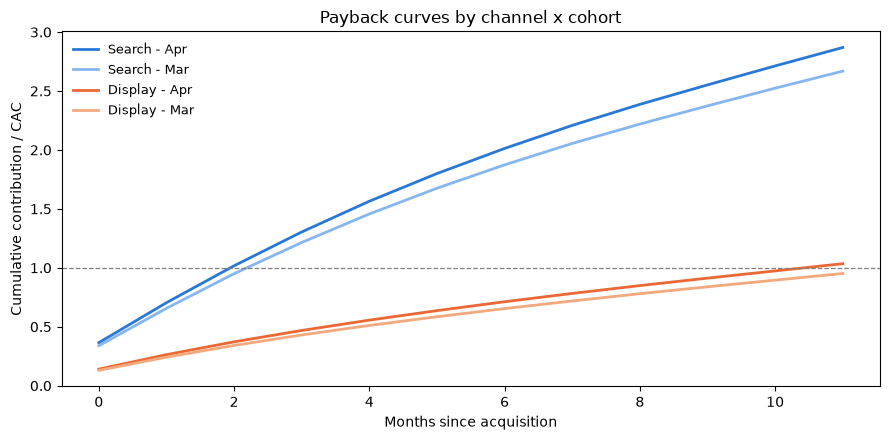

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.5))
styles = [("search", "2025-04", "#2a78d6", "Search - Apr"),
          ("search", "2025-03", "#86b6ef", "Search - Mar"),
          ("display", "2025-04", "#eb6834", "Display - Apr"),
          ("display", "2025-03", "#f3a97e", "Display - Mar")]
for ch, cm, color, label in styles:
    d = payback_df(ch, cm)
    ax.plot(d.m, d.cum, color=color, linewidth=2, label=label)
    cross = next((m for m, v in zip(d.m, d.cum) if v >= 1), None)
    msg = "미회수 (관측 구간 내)"
    if cross is not None:
        msg = f"M+{cross} ({cross + 1}개월째)"
    print(f"{label:<13}: payback = {msg}")

ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.9)
ax.set_xlabel("Months since acquisition")
ax.set_ylabel("Cumulative contribution / CAC")
ax.set_title("Payback curves by channel x cohort")
ax.legend(loc="upper left", frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

검색은 4월 코호트가 3월보다 한 달 빨리(3개월째 vs 4개월째) CAC에 도달했고, 디스플레이는
4월 코호트가 12개월째에 겨우 1.0을 넘었을 뿐 3월 코호트는 1년 안에 회수하지 못했습니다. 같은
채널에서 한 달 차이로 유입된 코호트인데도, 1년 안 회수 여부가 갈린 셈입니다. 채널 평균 숫자
하나로는 이런 차이가 보이지 않으니, 코호트별 곡선을 직접 그려서 확인해 보는 것이 좋습니다.


## 7.4.6. 회수 기간 기반 CAC 가이드라인

마지막으로 CAC 가이드라인 = 목표 회수 기간 × 유저당 월평균 공헌이익 공식에 따라
채널별 타깃 CAC를 구해 보겠습니다. 월평균 공헌이익은 장기 코호트의 12개월 실측을 12로 나눠
계산하고, 목표 회수 기간은 7.3.1의 가이드라인대로 12개월로 둡니다.


In [12]:
monthly = con.execute(f"""
    SELECT m.channel
         , SUM(p.amount_krw) * {CM_RATIO}
           / COUNT(DISTINCT m.user_id) / 12.0 AS avg_monthly_contrib
    FROM mature m
    LEFT JOIN payments p
      ON p.user_id = m.user_id
     AND p.payment_date < m.cohort_month + INTERVAL 12 MONTH
    WHERE m.channel != 'organic'
    GROUP BY 1
""").df()

TARGET_PAYBACK = 12  # 목표 회수 기간(개월) - 7.3.1의 '12개월 안에 회수' 기준
guide = monthly.merge(cac[["channel", "cac_fully_loaded"]], on="channel")
guide["avg_monthly_contrib"] = guide.avg_monthly_contrib.round(0)
guide["cac_guideline"] = (guide.avg_monthly_contrib * TARGET_PAYBACK).round(-2)
guide["current_vs_guide"] = (guide.cac_fully_loaded
                             / guide.cac_guideline).round(2)
guide[["channel", "avg_monthly_contrib", "cac_guideline",
       "cac_fully_loaded", "current_vs_guide"]].sort_values("current_vs_guide")

,channel,avg_monthly_contrib,cac_guideline,cac_fully_loaded,current_vs_guide
0,retargeting,2001.0,24000.0,3600.0,0.15
2,search,2750.0,33000.0,11500.0,0.35
1,display,492.0,5900.0,5700.0,0.97
3,brand,2001.0,24000.0,28000.0,1.17


목표 회수 기간을 12개월로 두면 브랜드 광고만 CAC 가이드라인을 초과하고, 디스플레이는
가이드라인의 97%로 턱걸이입니다. 리타겟팅은 여유가 커 보이는데, 캠페인 특성상 라스트 클릭
어트리뷰션이 효율을 부풀렸을 가능성이 있으니 이 숫자만 믿고 예산을 몰아주면 위험합니다.
월평균 공헌이익은 2024년 코호트 실측이고 CAC는 2025년 4월 값이라, 그 사이 결제 패턴이
바뀌지 않았는지도 함께 확인해야 합니다.

본문에서 이야기한 것처럼 목표 기간이 바뀌면 채널의 효율이 동일하다고 하더라도 CAC
가이드라인 준수 여부는 달라질 수 있습니다. (`TARGET_PAYBACK`을 8로 바꿔서 다시 실행해
보세요. 검색은 여전히 가이드라인 안이지만 디스플레이가 초과로 뒤집힙니다.)
